# Cross-Model SAE Feature-Level Gender Bias Experiments


In [1]:
# ══════════════════════════════════════════════════════════════════
# SELECT MODEL HERE
# ══════════════════════════════════════════════════════════════════
MODEL_KEY = "gpt2"   
N_FEATURE_CANDIDATES = 50  # top-N from each direction in discovery
BIAS_THRESHOLD_PCT = 5     # minimum abs_bias reduction % to count as "bias reducer"
MASS_THRESHOLD_PCT = 5     # maximum |mass change %| for "decoupled" features

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
import shutil
from collections import defaultdict
from pathlib import Path

from transformer_lens import HookedTransformer
from sae_lens import SAE

with open("splits.json") as f:
    SPLITS = json.load(f)

os.makedirs("data", exist_ok=True)
shutil.copy("splits.json", "data/splits.json")

def build_prompts(split_name):
    """Build prompts as 'The {occupation} {template}' for a named split."""
    s = SPLITS[split_name]
    return [f"The {occ} {tmpl}" for occ in s["occupations"] for tmpl in s["templates"]]

# Stereotype labels for the discovery split (used only for differential activation)
DISCOVERY_FEMALE_OCCS = [
    "nurse", "secretary", "teacher", "homemaker",
    "receptionist", "librarian", "nanny",
]
DISCOVERY_MALE_OCCS = [
    "doctor", "engineer", "CEO", "programmer", "mechanic",
    "pilot", "surgeon", "janitor", "waiter", "scientist",
    "journalist", "photographer", "musician",
]
assert (
    set(DISCOVERY_FEMALE_OCCS) | set(DISCOVERY_MALE_OCCS)
    == set(SPLITS["discovery"]["occupations"])
), "Discovery stereotype labels must cover the full discovery split."

# ── Model config  ──
from model_configs import MODELS, RUNNABLE_MODELS

# ── SAE hook factories + bias metrics with CIs ──
from metrics import (
    compute_bias_metrics, compute_bias_metrics_with_ci,
    compute_stereotype_amplification,
    get_sae_activations_for_prompts,
    make_sae_feature_clamp_hook, make_multi_feature_clamp_hook,
)

import eval_utils


/orcd/software/core/001/pkg/miniforge/25.11.0-0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Setup: Load Model and SAE

In [3]:
# Validate model selection
assert MODEL_KEY in RUNNABLE_MODELS, (
    f"{MODEL_KEY} not runnable. Available: {list(RUNNABLE_MODELS.keys())}. "
    f"OLMo has no SAE-Lens SAEs yet."
)
cfg = MODELS[MODEL_KEY]
print(f"Model: {cfg['display_name']}")
print(f"  Layers: {cfg['n_layers']}, d_model: {cfg['d_model']}")
print(f"  SAE: {cfg['sae_release']} / {cfg['sae_id']}")
print(f"  Hook: {cfg['hook_name']} (layer {cfg['sae_layer']})")

Model: GPT-2 Small
  Layers: 12, d_model: 768
  SAE: gpt2-small-res-jb / blocks.11.hook_resid_pre
  Hook: blocks.10.hook_resid_post (layer 10)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load model
model = HookedTransformer.from_pretrained(cfg["model_id"], device=device)
model.eval()
print(f"Model loaded: {cfg['display_name']}")

Device: cuda


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 22973.98it/s]


Loaded pretrained model gpt2 into HookedTransformer
Model loaded: GPT-2 Small


In [5]:
# Load SAE
sae = SAE.from_pretrained(
    release=cfg["sae_release"],
    sae_id=cfg["sae_id"],
    device=device,
)[0]
HOOK_NAME = cfg["hook_name"]
SAE_LAYER = cfg["sae_layer"]
print(f"SAE loaded: {sae.cfg.d_sae} features, d_model={sae.cfg.d_in}")

SAE loaded: 24576 features, d_model=768


/home/ayela/.local/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
/tmp/ipykernel_320/685252942.py:2: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae = SAE.from_pretrained(


In [6]:
# Canonical token strings
MALE_TOKEN_STRINGS   = [" he", " him", " his", " himself"]
FEMALE_TOKEN_STRINGS = [" she", " her", " hers", " herself"]

def _safe_token_id(model, s):
    """Resolve a (possibly multi-token) string to its first token ID."""
    toks = model.to_tokens(s, prepend_bos=False).squeeze()
    return toks.item() if toks.dim() == 0 else toks[0].item()

male_token_ids   = [_safe_token_id(model, s) for s in MALE_TOKEN_STRINGS]
female_token_ids = [_safe_token_id(model, s) for s in FEMALE_TOKEN_STRINGS]
print(f"Male tokens   {MALE_TOKEN_STRINGS} -> {male_token_ids}")
print(f"Female tokens {FEMALE_TOKEN_STRINGS} -> {female_token_ids}")

# Make eval_utils share these IDs (avoids re-resolving with its own logic)
eval_utils.get_gender_ids = lambda m: (male_token_ids, female_token_ids)

# Seed eval_utils' bootstrap
def _seeded_bootstrap_ci(data, n_boot=10000, ci=0.95,
                          _rng=np.random.default_rng(42)):
    if len(data) == 0:
        return (0.0, 0.0)
    data = np.asarray(data)
    means = np.array([
        _rng.choice(data, size=len(data), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = (1 - ci) / 2
    return (
        float(np.percentile(means, 100 * alpha)),
        float(np.percentile(means, 100 * (1 - alpha))),
    )
eval_utils.bootstrap_ci = _seeded_bootstrap_ci


Male tokens   [' he', ' him', ' his', ' himself'] -> [339, 683, 465, 2241]
Female tokens [' she', ' her', ' hers', ' herself'] -> [673, 607, 25144, 5223]


## 1. Build Prompts

In [7]:
discovery_prompts = build_prompts("discovery")
dev_prompts       = build_prompts("dev")
test_prompts      = build_prompts("test")
print(f"Discovery: {len(discovery_prompts)} prompts")
print(f"Dev:       {len(dev_prompts)} prompts")
print(f"Test:      {len(test_prompts)} prompts")


Discovery: 200 prompts
Dev:       200 prompts
Test:      250 prompts


## 2. Baseline Measurements

**Split discipline:**
- `discovery_prompts` — find candidate features (Sec. 3)
- `dev_prompts`       — sweep + tune interventions (Secs. 2, 4, 5)
- `test_prompts`      — final reported numbers (Secs. 8, 9)


In [8]:
print("Computing baseline metrics on DEV split...")
dev_occs_list = SPLITS["dev"]["occupations"]
dev_templates_list = SPLITS["dev"]["templates"]

baseline = compute_bias_metrics(dev_prompts, model, male_token_ids, female_token_ids)
baseline_amp = compute_stereotype_amplification(
    dev_prompts, dev_occs_list, dev_templates_list, model,
    male_token_ids, female_token_ids,
)

print(f"Baseline abs_bias:      {baseline['abs_bias']:.4f}")
print(f"Baseline signed_bias:   {baseline['signed_bias']:.4f}")
print(f"Baseline gender_mass:   {baseline['gender_mass']:.4f}")
print(f"Baseline amplification: {baseline_amp['amplification']:.4f}")


Computing baseline metrics on DEV split...
Baseline abs_bias:      0.1230
Baseline signed_bias:   0.0738
Baseline gender_mass:   0.1962
Baseline amplification: 0.1097


## 3. SAE Feature Discovery

In [9]:
print("Collecting SAE feature activations on DISCOVERY prompts...")
sae_acts = get_sae_activations_for_prompts(discovery_prompts, model, sae, layer=SAE_LAYER)
print(f"SAE activations shape: {sae_acts.shape}")


SAE activations shape: torch.Size([200, 24576])


In [10]:
# Differential activation: male-occ vs female-occ prompts on the discovery split.
# Note: discovery split lists occupations in the order from splits.json, which is
# NOT grouped by stereotype — so we filter by occupation membership rather than
# using positional indices.

discovery_occs = SPLITS["discovery"]["occupations"]
discovery_templates = SPLITS["discovery"]["templates"]
n_templates = len(discovery_templates)

male_occ_indices = []
female_occ_indices = []
for occ_idx, occ in enumerate(discovery_occs):
    prompt_indices = list(range(occ_idx * n_templates, (occ_idx + 1) * n_templates))
    if occ in DISCOVERY_MALE_OCCS:
        male_occ_indices.extend(prompt_indices)
    elif occ in DISCOVERY_FEMALE_OCCS:
        female_occ_indices.extend(prompt_indices)

print(f"Male-stereo prompts:   {len(male_occ_indices)}")
print(f"Female-stereo prompts: {len(female_occ_indices)}")

male_occ_acts   = sae_acts[male_occ_indices].mean(dim=0)
female_occ_acts = sae_acts[female_occ_indices].mean(dim=0)
diff_activation = male_occ_acts - female_occ_acts
overall_activation = sae_acts.mean(dim=0)

# Top candidates
top_male_biased = torch.argsort(diff_activation, descending=True)[:N_FEATURE_CANDIDATES]
top_female_biased = torch.argsort(diff_activation, descending=False)[:N_FEATURE_CANDIDATES]

# Include known features if any (model-specific)
known_fids = [v for v in cfg["known_features"].values() if v is not None]
all_candidate_ids = list(set(
    top_male_biased.tolist() + top_female_biased.tolist() + known_fids
))

print(f"\nTop male-biased features:")
for fid in top_male_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTop female-biased features:")
for fid in top_female_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTotal candidate features: {len(all_candidate_ids)}")


Male-stereo prompts:   130
Female-stereo prompts: 70

Top male-biased features:
  F837: diff=1.9778, overall=1.4636
  F14652: diff=1.1063, overall=1.2733
  F7055: diff=1.0951, overall=8.2016
  F17896: diff=0.9253, overall=0.6732
  F9515: diff=0.8905, overall=0.8515
  F2376: diff=0.8516, overall=1.5833
  F21942: diff=0.8409, overall=0.5466
  F13598: diff=0.8360, overall=0.7189
  F11186: diff=0.7702, overall=0.5006
  F12057: diff=0.7447, overall=0.5124

Top female-biased features:
  F23772: diff=-2.8270, overall=1.1344
  F4077: diff=-2.2237, overall=0.9294
  F1253: diff=-1.2450, overall=2.6506
  F17632: diff=-1.1890, overall=0.4765
  F11223: diff=-1.1886, overall=0.4160
  F4772: diff=-0.8745, overall=0.3061
  F7628: diff=-0.8553, overall=2.1014
  F15346: diff=-0.7794, overall=5.9095
  F17442: diff=-0.7639, overall=1.4253
  F12450: diff=-0.7350, overall=1.9092

Total candidate features: 102


## 4. Feature Clamping Sweep

In [11]:
print("Feature clamping sweep on DEV split (clamp each candidate to zero, measure bias + mass)...")
feature_results = []

dev_occs_list = SPLITS["dev"]["occupations"]
dev_templates_list = SPLITS["dev"]["templates"]

for fid in tqdm(all_candidate_ids, desc="Feature clamping sweep"):
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)

    metrics = compute_bias_metrics(
        dev_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )
    amp_metrics = compute_stereotype_amplification(
        dev_prompts, dev_occs_list, dev_templates_list, model,
        male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )

    feature_results.append({
        "feature_id": fid,
        "abs_bias": metrics["abs_bias"],
        "signed_bias": metrics["signed_bias"],
        "gender_mass": metrics["gender_mass"],
        "amplification": amp_metrics["amplification"],
        "mean_signed": amp_metrics["mean_signed"],
        "abs_bias_reduction_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
        "signed_bias_change": metrics["signed_bias"] - baseline["signed_bias"],
        "gender_mass_change_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        "amp_reduction_pct": (baseline_amp["amplification"] - amp_metrics["amplification"]) / baseline_amp["amplification"] * 100,
        "diff_activation": diff_activation[fid].item(),
    })

df = pd.DataFrame(feature_results)
print(f"Sweep complete: {len(df)} features evaluated.")


Feature clamping sweep on DEV split (clamp each candidate to zero, measure bias + mass)...


Feature clamping sweep: 100%|██████████| 102/102 [04:57<00:00,  2.91s/it]

Sweep complete: 102 features evaluated.


## 5. Analysis: Selectivity, Pareto Plot, Decoupled Features

In [12]:
df["selectivity"] = df["abs_bias_reduction_pct"] / (df["gender_mass_change_pct"].abs() + 1)

bias_reducers = df[df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT].sort_values("selectivity", ascending=False)
print(f"Features with >{BIAS_THRESHOLD_PCT}% abs bias reduction: {len(bias_reducers)}")
if len(bias_reducers) > 0:
    print(bias_reducers[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                          "gender_mass_change_pct", "amp_reduction_pct", "selectivity"]].head(20).to_string())

decoupled = df[
    (df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT) &
    (df["gender_mass_change_pct"].abs() < MASS_THRESHOLD_PCT)
]
print(f"\nDecoupled features (>{BIAS_THRESHOLD_PCT}% bias red, <{MASS_THRESHOLD_PCT}% mass change): {len(decoupled)}")
if len(decoupled) > 0:
    print("*** POSITIVE RESULT: Found features that decouple bias from mass! ***")
    print(decoupled[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                      "gender_mass_change_pct", "selectivity"]].to_string())
else:
    print("Negative result: No features found that decouple bias from gender mass suppression.")
    print("This strengthens the claim that bias and gender encoding are fundamentally entangled.")

Features with >5% abs bias reduction: 5
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  amp_reduction_pct  selectivity
37       23772                5.768536            0.012303               -0.614611          15.918646     3.572709
97        4077               10.284746            0.017599               -2.119482          25.356489     3.296941
62         837               14.810825           -0.019037               -5.143456           9.463777     2.410830
59       14652                5.929283           -0.012553               -1.582183           1.750786     2.296229
64       16213                6.551898           -0.009904               -3.983784           3.768155     1.314643

Decoupled features (>5% bias red, <5% mass change): 4
*** POSITIVE RESULT: Found features that decouple bias from mass! ***
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  selectivity
37       23772                5.768536           

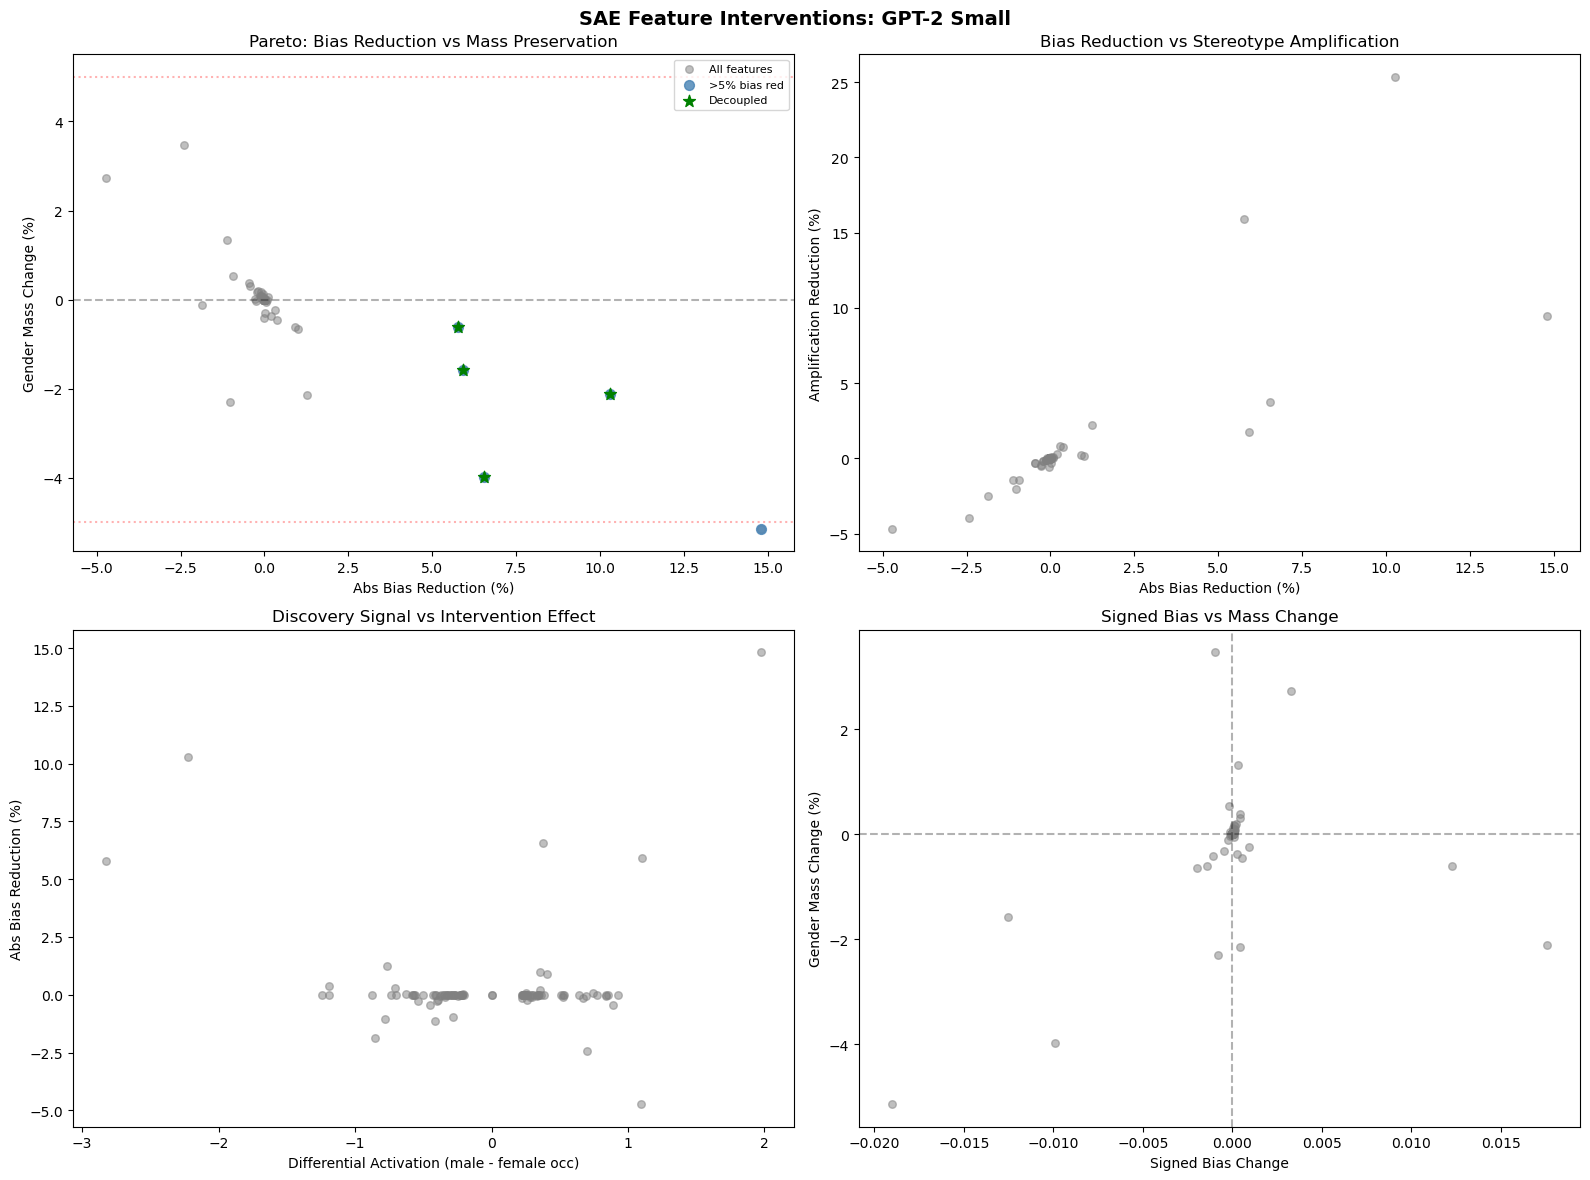

Saved: results_gpt2_pareto.png


In [13]:
# Pareto plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"SAE Feature Interventions: {cfg['display_name']}",
             fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.scatter(df["abs_bias_reduction_pct"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray", label="All features")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["abs_bias_reduction_pct"], bias_reducers["gender_mass_change_pct"],
               alpha=0.8, s=50, c="steelblue", label=f">{BIAS_THRESHOLD_PCT}% bias red")
if len(decoupled) > 0:
    ax.scatter(decoupled["abs_bias_reduction_pct"], decoupled["gender_mass_change_pct"],
               alpha=1.0, s=80, c="green", marker="*", label="Decoupled")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axhline(y=-MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.axhline(y=MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Pareto: Bias Reduction vs Mass Preservation")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(df["abs_bias_reduction_pct"], df["amp_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Amplification Reduction (%)")
ax.set_title("Bias Reduction vs Stereotype Amplification")

ax = axes[1, 0]
ax.scatter(df["diff_activation"], df["abs_bias_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Differential Activation (male - female occ)")
ax.set_ylabel("Abs Bias Reduction (%)")
ax.set_title("Discovery Signal vs Intervention Effect")

ax = axes[1, 1]
ax.scatter(df["signed_bias_change"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Signed Bias Change")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Signed Bias vs Mass Change")

plt.tight_layout()
plt.savefig(f"results_{cfg['name']}_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: results_{cfg['name']}_pareto.png")

In [16]:
SWEEP_FEATURES = (df.sort_values("abs_bias_reduction_pct", ascending=False)
                    .head(3)["feature_id"].astype(int).tolist())

F16213 scale sweep: 100%|██████████| 9/9 [00:13<00:00,  1.46s/it]


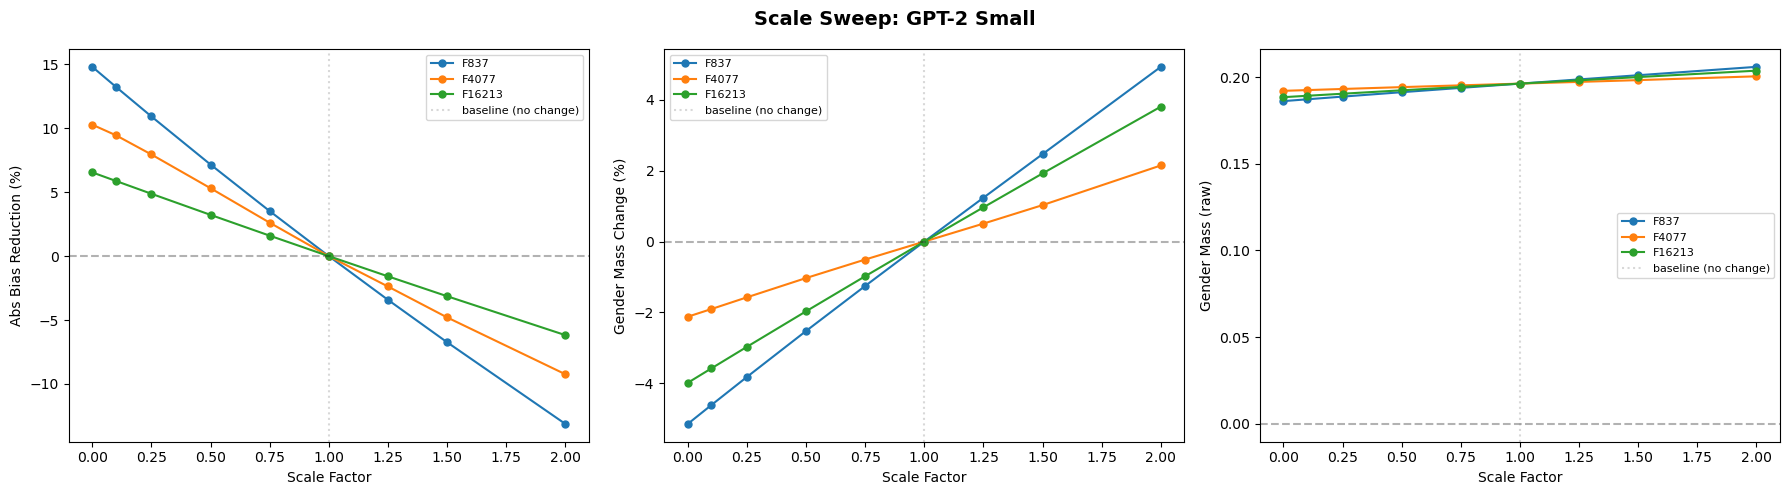

F837: bias-mass correlation r=-1.000 (linear entanglement)
F4077: bias-mass correlation r=-0.999 (linear entanglement)
F16213: bias-mass correlation r=-1.000 (linear entanglement)


In [17]:
# ══════════════════════════════════════════════════════════════════
# Scale sweep: titrate intervention strength for top features
# ══════════════════════════════════════════════════════════════════

SCALES = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

sweep_results = []
for fid in SWEEP_FEATURES:
    for scale in tqdm(SCALES, desc=f"F{fid} scale sweep"):
        hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=scale)
        metrics = compute_bias_metrics(
            dev_prompts, model, male_token_ids, female_token_ids,
            hook_fn=hook_fn, hook_name=HOOK_NAME,
        )
        sweep_results.append({
            "feature_id": fid,
            "scale": scale,
            "abs_bias": metrics["abs_bias"],
            "signed_bias": metrics["signed_bias"],
            "gender_mass": metrics["gender_mass"],
            "abs_bias_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
            "mass_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        })

sweep_df = pd.DataFrame(sweep_results)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Scale Sweep: {cfg['display_name']}", fontsize=14, fontweight="bold")

for ax, (metric, ylabel) in zip(axes, [
    ("abs_bias_pct", "Abs Bias Reduction (%)"),
    ("mass_pct", "Gender Mass Change (%)"),
    ("gender_mass", "Gender Mass (raw)"),
]):
    for fid in SWEEP_FEATURES:
        fdf = sweep_df[sweep_df["feature_id"] == fid]
        ax.plot(fdf["scale"], fdf[metric], "o-", label=f"F{fid}", markersize=5)
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
    ax.axvline(x=1.0, color="gray", linestyle=":", alpha=0.3, label="baseline (no change)")
    ax.set_xlabel("Scale Factor")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"results_{cfg['name']}_scale_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Linearity check: correlation between bias reduction and mass change
for fid in SWEEP_FEATURES:
    fdf = sweep_df[sweep_df["feature_id"] == fid]
    corr = np.corrcoef(fdf["abs_bias_pct"], fdf["mass_pct"])[0, 1]
    print(f"F{fid}: bias-mass correlation r={corr:.3f} ({'linear entanglement' if abs(corr) > 0.9 else 'nonlinear — partial decoupling possible'})")

## 6. Feature Characterisation (Logit Lens)

In [18]:
# Characterise top decoupled features (if any) and top bias reducers
features_to_check = {}
if len(decoupled) > 0:
    for _, row in decoupled.head(5).iterrows():
        fid = int(row["feature_id"])
        features_to_check[f"F{fid} (decoupled)"] = fid
if len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        if fid not in features_to_check.values():
            features_to_check[f"F{fid} (bias reducer)"] = fid
# Add known features
for name, fid in cfg["known_features"].items():
    features_to_check[name] = fid

print(f"Characterising {len(features_to_check)} features...")
for name, fid in features_to_check.items():
    print(f"\n--- {name} (feature {fid}) ---")

    # Logit lens
    feature_dir = sae.W_dec[fid]
    logit_contributions = model.W_U.T @ feature_dir

    top_pos = torch.topk(logit_contributions, k=15)
    top_neg = torch.topk(logit_contributions, k=15, largest=False)

    print("  Top PROMOTED tokens:")
    for i in range(15):
        tok = model.to_string([top_pos.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_pos.values[i].item():+.3f}")

    print("  Top SUPPRESSED tokens:")
    for i in range(15):
        tok = model.to_string([top_neg.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_neg.values[i].item():+.3f}")

    # Prompt activations on the discovery split
    feature_acts = sae_acts[:, fid]
    top_prompt_idx = torch.topk(feature_acts, k=min(10, len(discovery_prompts))).indices
    print("  Top ACTIVATING prompts:")
    for idx in top_prompt_idx:
        print(f"    [{feature_acts[idx]:.3f}] {discovery_prompts[idx]}")

    # Gender specificity (using indices computed in cell 14)
    male_mean   = feature_acts[male_occ_indices].mean().item()
    female_mean = feature_acts[female_occ_indices].mean().item()
    print(f"  Male-occ mean:   {male_mean:.4f}")
    print(f"  Female-occ mean: {female_mean:.4f}")
    print(f"  Differential:    {male_mean - female_mean:.4f}")


Characterising 7 features...

--- F23772 (decoupled) (feature 23772) ---
  Top PROMOTED tokens:
         ' herself'  +2.154
             ' her'  +1.829
             ' she'  +1.575
            ' hers'  +1.565
              'She'  +1.403
             ' She'  +1.355
             ' SHE'  +1.322
              'Her'  +1.251
              'she'  +1.235
             ' HER'  +1.194
         ' husband'  +1.152
       ' boyfriend'  +1.136
             ' Her'  +1.125
       ' pregnancy'  +1.118
          ' bikini'  +1.113
  Top SUPPRESSED tokens:
                '版'  -0.597
            'espie'  -0.595
             'uden'  -0.567
                'ワ'  -0.539
              'sov'  -0.534
            'opoly'  -0.533
              'yip'  -0.532
    ' Transactions'  -0.527
          'Players'  -0.524
                '代'  -0.524
          'players'  -0.518
                '�'  -0.511
         'Magikarp'  -0.511
             'atos'  -0.506
    ' Infrastructure'  -0.495
  Top ACTIVATING prompts:
    [9.461]

## 7. Build Interventions for Full Evaluation

Based on the discovery results, build intervention configs.
If decoupled features were found, test them individually and in combinations.
If not, test the top bias reducers anyway (to characterise the mass cost).

In [19]:
# Auto-build interventions from discovery results
INTERVENTIONS = {"Baseline": None}

# Add top individual features
top_features_for_eval = []
if len(decoupled) > 0:
    for _, row in decoupled.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)
elif len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)

# Add combinations if we have 2+ features
if len(top_features_for_eval) >= 2:
    combo_name = " + ".join(f"F{f}" for f in top_features_for_eval[:2])
    INTERVENTIONS[combo_name] = {f: 0.0 for f in top_features_for_eval[:2]}
if len(top_features_for_eval) >= 3:
    INTERVENTIONS["All three"] = {f: 0.0 for f in top_features_for_eval[:3]}
    # Half-scale variant
    INTERVENTIONS[f"F{top_features_for_eval[0]} (half) + F{top_features_for_eval[1]}"] = {
        top_features_for_eval[0]: 0.5, top_features_for_eval[1]: 0.0
    }

print("Interventions to evaluate:")
for name, spec in INTERVENTIONS.items():
    print(f"  {name}: {spec}")

Interventions to evaluate:
  Baseline: None
  F23772: {23772: 0.0}
  F14652: {14652: 0.0}
  F16213: {16213: 0.0}
  F23772 + F14652: {23772: 0.0, 14652: 0.0}
  All three: {23772: 0.0, 14652: 0.0, 16213: 0.0}
  F23772 (half) + F14652: {23772: 0.5, 14652: 0.0}


In [20]:
def get_hook_for_intervention(intervention_dict):
    """Return (hook_fn, hook_name) for an intervention spec."""
    if intervention_dict is None:
        return None, None
    if len(intervention_dict) == 1:
        fid, scale = list(intervention_dict.items())[0]
        return make_sae_feature_clamp_hook(sae, fid, scale=scale), HOOK_NAME
    else:
        return make_multi_feature_clamp_hook(sae, intervention_dict), HOOK_NAME

## 8. Test-Set Bias Metrics + Bootstrap CIs

In [21]:
print("Test-set evaluation with bootstrap CIs...")
test_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  Evaluating: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    result = compute_bias_metrics_with_ci(
        test_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    test_results[name] = result
    print(f"    abs_bias={result['abs_bias']:.4f} [{result['abs_bias_ci'][0]:.4f}, {result['abs_bias_ci'][1]:.4f}]")
    print(f"    signed ={result['signed_bias']:.4f}, mass={result['gender_mass']:.4f}")

Test-set evaluation with bootstrap CIs...
  Evaluating: Baseline...


    abs_bias=0.0788 [0.0710, 0.0869]
    signed =0.0593, mass=0.1892
  Evaluating: F23772...


    abs_bias=0.0766 [0.0691, 0.0846]
    signed =0.0651, mass=0.1885
  Evaluating: F14652...


    abs_bias=0.0712 [0.0639, 0.0790]
    signed =0.0505, mass=0.1876
  Evaluating: F16213...


    abs_bias=0.0736 [0.0666, 0.0810]
    signed =0.0536, mass=0.1845
  Evaluating: F23772 + F14652...


    abs_bias=0.0688 [0.0618, 0.0763]
    signed =0.0564, mass=0.1870
  Evaluating: All three...


    abs_bias=0.0636 [0.0573, 0.0703]
    signed =0.0506, mass=0.1823
  Evaluating: F23772 (half) + F14652...


    abs_bias=0.0699 [0.0627, 0.0775]
    signed =0.0534, mass=0.1874


## 9. Full Evaluation Suite (`eval_utils.full_eval`)

Runs WikiText-103 PPL, LAMBADA, BLiMP, Winogender, WinoBias, CrowS-Pairs, and
GAP for every intervention.


In [22]:
# Run the full evaluation suite for every intervention (test split).
eval_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"\n  Running full eval: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    hooks = [(hook_name, hook_fn)] if hook_fn is not None else None
    eval_results[name] = eval_utils.full_eval(
        model, hooks=hooks, split="test", capability="full",
        n_boot=10000, verbose=True,
    )
    eval_utils.print_results(eval_results[name], label=name)



  Running full eval: Baseline...
  [bias] Evaluating on test split...
  [capability] WikiText-103 PPL (1000 sentences)...
  [coref] Winogender...
  [capability] LAMBADA (500 examples)...
  [capability] BLiMP minimal pairs...


Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 198744.50 examples/s]


  [coref] WinoBias (pro/anti stereotypical)...


Generating test split: 100%|██████████| 396/396 [00:00<00:00, 73832.88 examples/s]


  [bias] CrowS-Pairs (~262 gender pairs)...
  [coref] GAP (Wikipedia pronoun coreference)...

Baseline

  BIAS METRICS (250 prompts):
    Signed bias:          +0.0593 [0.0488, 0.0697]
    Absolute bias:         0.0788 [0.0707, 0.0869]
    Total gender mass:     0.1892
    Stereotype pref (>M):  87.2%

  CAPABILITY:
    WikiText-103 PPL:     123.60 [111.1544, 138.8695]
    LAMBADA accuracy:     24.8% [0.2100, 0.2860]
    BLiMP mean:           98.2%
      anaphor_gender_agreement       99.7%
      regular_plural_subject_verb_agreement_1 96.6%

  COREFERENCE:
    Winogender male pref: 78.8% (240 pairs) [0.7333, 0.8375]
      he/she               82.0% male
      his/her              75.9% male
      him/her              25.0% male
    WinoBias Type1 pro:   54.5%
    WinoBias Type1 anti:  54.0%
    WinoBias Type1 gap:   0.5 pp
    WinoBias Type2 pro:   64.4%
    WinoBias Type2 anti:  40.2%
    WinoBias Type2 gap:   24.2 pp
    GAP overall:          70.6% (M: 70.5%, F: 70.7%)

  BIAS BENCH

*LAMBADA, BLiMP, Winogender, and CrowS-Pairs are now run inside `eval_utils.full_eval` above.*


*WinoBias and GAP are also covered by `eval_utils.full_eval` (test split).*


*All capability evaluations run on the canonical `data/splits.json` test split with seeded bootstrap CIs.*


*See `eval_utils.print_results(...)` output above for per-intervention details.*


## 10. Summary Table

In [23]:
# Build the summary table
def fmt_signed(x): return f"{x:+.4f}"
def fmt_pos(x):    return f"{x:.4f}"
def fmt_pct(x):    return f"{x*100:.1f}"
def fmt_pp(x):     return f"{x*100:+.1f}"  # percentage-point gap

rows = []
for name in INTERVENTIONS:
    r = eval_results[name]
    blimp_mean = r.get("blimp", {}).get("mean", float("nan"))
    rows.append({
        "Intervention":   name,
        "Signed Bias↓":   fmt_signed(r["signed_bias"]),
        "Abs Bias↓":      fmt_pos(r["abs_bias"]),
        "Gender Mass":    fmt_pos(r["total_gender_mass"]),
        "WikiText PPL↓":  f"{r['wikitext_ppl']:.2f}",
        "LAMBADA (%)↑":   fmt_pct(r["lambada_acc"]),
        "BLiMP (%)↑":     fmt_pct(blimp_mean),
        "Winogender%":    fmt_pct(r["winogender_male_pref"]),
        "GAP (%)↑":       fmt_pct(r["gap_overall"]),
        "CrowS (%)↓":     fmt_pct(r["crows_pairs_score"]),
        "WinoB T1 gap↓":  fmt_pp(r["winobias_type1_gap"]),
        "WinoB T2 gap↓":  fmt_pp(r["winobias_type2_gap"]),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


          Intervention Signed Bias↓ Abs Bias↓ Gender Mass WikiText PPL↓ LAMBADA (%)↑ BLiMP (%)↑ Winogender% GAP (%)↑ CrowS (%)↓ WinoB T1 gap↓ WinoB T2 gap↓
              Baseline      +0.0593    0.0788      0.1892        123.60         24.8       98.2        78.8     70.6       60.7          +0.5         +24.2
                F23772      +0.0651    0.0766      0.1885        123.60         24.8       98.2        81.2     70.6       60.7          -0.5         +22.7
                F14652      +0.0505    0.0712      0.1876        123.60         24.8       98.2        78.3     70.6       60.7          +0.0         +23.7
                F16213      +0.0536    0.0736      0.1845        123.60         24.8       98.2        78.3     70.6       60.7          +0.5         +24.5
       F23772 + F14652      +0.0564    0.0688      0.1870        123.60         24.8       98.2        81.2     70.6       60.7          -0.5         +23.5
             All three      +0.0506    0.0636      0.1823       

## 11. Save Results

In [24]:
results_dir = f"results/{cfg['name']}_sae_male_skew"
os.makedirs(results_dir, exist_ok=True)

# Per-feature sweep
df.to_csv(f"{results_dir}/feature_sweep.csv", index=False)

# Summary CSV
summary_df.to_csv(f"{results_dir}/summary_table.csv", index=False)

# LaTeX table matching the paper format
def to_latex_table(df, caption, label):
    cols = df.columns.tolist()
    body_rows = [" & ".join(str(v) for v in row.values) + r" \\"
                 for _, row in df.iterrows()]
    return "\n".join([
        r"\begin{table}[h]",
        r"\centering",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        r"\begin{tabular}{l" + "c" * (len(cols) - 1) + "}",
        r"\toprule",
        " & ".join(cols) + r" \\",
        r"\midrule",
        *body_rows,
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])

latex = to_latex_table(
    summary_df,
    caption=f"{cfg['display_name']} test-set evaluation across interventions.",
    label=f"tab:{cfg['name']}_eval",
)
with open(f"{results_dir}/summary_table.tex", "w") as f:
    f.write(latex)

# Full eval results JSON (strip numpy arrays / private keys)
def _clean(d):
    out = {}
    for k, v in d.items():
        if k.startswith("_"):
            continue
        if isinstance(v, np.ndarray):
            continue
        if isinstance(v, dict):
            out[k] = _clean(v)
        elif isinstance(v, (np.floating, np.integer)):
            out[k] = float(v)
        else:
            out[k] = v
    return out

all_results = {
    "model": cfg["name"],
    "model_display": cfg["display_name"],
    "sae_release": cfg["sae_release"],
    "sae_id": cfg["sae_id"],
    "interventions": {k: v for k, v in INTERVENTIONS.items()},
    "eval_results": {name: _clean(r) for name, r in eval_results.items()},
    "n_decoupled_features": len(decoupled),
    "n_bias_reducers": len(bias_reducers),
    "splits_used": {
        "discovery": SPLITS["discovery"],
        "dev":       SPLITS["dev"],
        "test":      SPLITS["test"],
    },
    "token_strings": {
        "male":   MALE_TOKEN_STRINGS,
        "female": FEMALE_TOKEN_STRINGS,
    },
}

with open(f"{results_dir}/full_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)

print(f"\nAll results saved to {results_dir}/")
print(f"  feature_sweep.csv    — per-feature clamping results")
print(f"  summary_table.csv    — paper Table 2 summary")
print(f"  summary_table.tex    — LaTeX-ready table")
print(f"  full_results.json    — all evaluation metrics + config")



All results saved to results/gpt2_sae_male_skew/
  feature_sweep.csv    — per-feature clamping results
  summary_table.csv    — paper Table 2 summary
  summary_table.tex    — LaTeX-ready table
  full_results.json    — all evaluation metrics + config
